In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO
import torchinfo
import os

# 1. Environment Setup & Hardware Verification
print(f"PyTorch Version: {torch.__version__}")

# Verify PyTorch recognizes the AMD GPU natively via ROCm
print(f"HIP/ROCm version built with PyTorch: {torch.version.hip}")
print(f"Is GPU Acceleration available? {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

# Assign device dynamically
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch Version: 2.11.0+rocm7.2
HIP/ROCm version built with PyTorch: 7.2.26015
Is GPU Acceleration available? True
Device Name: AMD Radeon RX 6800S


## 2. Data Loading & Preprocessing

The standard YOLO classifier takes images with shape `[3, 224, 224]`. Here we construct our `DataLoaders`, scaling all characters accordingly while normalizing the color channels for optimal feature mapping.


In [2]:
# Paths to your dataset according to the project structure
train_dir = "./data/final/train"
val_dir = "./data/final/val"

# Training transforms with Augmentation
train_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomRotation(
            degrees=15, fill=255
        ),  # Slight rotations, fill with white
        transforms.RandomAffine(
            degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2), fill=255
        ),  # Shift and scale
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# Validation transforms (NO Augmentation, just structural alignment)
val_transform = transforms.Compose(
    [
        transforms.Resize(
            (224, 224)
        ),  # Force resize so PyTorch DataLoader doesn't crash on variable sizes
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# Create Dataset objects using the separate transforms
train_dataset = ImageFolder(root=train_dir, transform=train_transform)
val_dataset = ImageFolder(root=val_dir, transform=val_transform)

# DataLoaders for vectorizing inputs in batches
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

classes = train_dataset.classes
print(f"Loaded {len(classes)} classes: {classes}")
print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")

# Verify the tensor dimensions:
# Should output [Batch_Size, Color_Channels, Height, Width] -> [32, 3, 224, 224]
sample_batch, sample_labels = next(iter(train_loader))
print(f"Batch shape check: {sample_batch.shape}")

Loaded 20 classes: ['ba', 'ca', 'da', 'dha', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'tha', 'wa', 'ya']
Train samples: 2154 | Val samples: 480
Batch shape check: torch.Size([32, 3, 224, 224])


## 3. Model Initialization & Architecture Inspection

We load the YOLO26 nano classification architecture (`yolo26n-cls.pt`). Since we need strict white-box feature extraction control, we'll extract the underlying PyTorch `nn.Module` from the Ultralytics wrapper.

This enables two things:

1. Complete transparency of tensor matrix transformations (from $3 \times 224 \times 224$ to a flat feature pool, culminating in a 20-dimension output vector).
2. Proper hook placement on the penultimate Convolutional spatial layer for **Grad-CAM**.


In [3]:
# Load the YOLO model natively
model_wrapper = YOLO("yolo26n-cls.pt")

# Extract actual pytorch nn.Module from wrapper to expose hooks natively to Captum/Grad-CAM
base_model = model_wrapper.model

# The pre-trained YOLO model was trained on ImageNet and outputs 1000 classes.
# We must replace the final linear classification layer to output our 20 Aksara Jawa classes instead.
in_features = base_model.model[-1].linear.in_features
base_model.model[-1].linear = nn.Linear(in_features, len(classes))

base_model = base_model.to(device)

# Ensure parameters require gradients for fine-tuning
for param in base_model.parameters():
    param.requires_grad = True

# Ensure the final output layer correctly targets [Batch, 20] corresponding to our 20 Aksara Jawa classes
# Note: typically YOLO classifiers end in a sequential block. We will just let torchinfo map it:
print("\n--- Model Architecture & Forward Pass Shape Verification ---")
torchinfo.summary(
    base_model,
    input_size=(batch_size, 3, 224, 224),
    col_names=["input_size", "output_size", "num_params"],
    depth=4,
)

# We will need the final convolutional block for Grad-CAM.
# Generally in Ultralytics this is the layer immediately before the final GAP (Global Average Pooling) and Linear layer.
# Printing model layers to find target `target_layer = base_model...` is handled later in the XAI section.


--- Model Architecture & Forward Pass Shape Verification ---


Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #
ClassificationModel                                          [32, 3, 224, 224]         [32, 20]                  --
├─Sequential: 1-1                                            --                        --                        --
│    └─Conv: 2-1                                             [32, 3, 224, 224]         [32, 16, 112, 112]        --
│    │    └─Conv2d: 3-1                                      [32, 3, 224, 224]         [32, 16, 112, 112]        432
│    │    └─BatchNorm2d: 3-2                                 [32, 16, 112, 112]        [32, 16, 112, 112]        32
│    │    └─SiLU: 3-3                                        [32, 16, 112, 112]        [32, 16, 112, 112]        --
│    └─Conv: 2-2                                             [32, 16, 112, 112]        [32, 32, 56, 56]          --
│    │    └─Conv2d: 3-4                                      [32, 

In [4]:
# --- Torchviz Integration ---
from torchviz import make_dot

print("\n--- Generating Computational Graph with Torchviz ---")
# 1. Initialize dummy input matching our batch and image dimensions
dummy_input = torch.randn(32, 3, 224, 224).to(device)

# 2. Forward pass to trace the graph
base_model.eval()  # Good practice to set to eval when tracing graphs
with torch.autocast(device_type="cuda"):
    outputs = base_model(dummy_input)

# Handle YOLO tuple output wrapper natively if it exists
if isinstance(outputs, tuple) or isinstance(outputs, list):
    y = outputs[0]
else:
    y = outputs

# 3. Create the graph diagram
# Passing base_model.named_parameters() populates the layer names correctly.
dot = make_dot(
    y, params=dict(base_model.named_parameters()), show_attrs=True, show_saved=True
)
dot.format = "png"
dot.render("images/model_computation_graph")
print(
    "Successfully generated and saved Torchviz computation graph to: 'images/model_computation_graph.png'"
)


--- Generating Computational Graph with Torchviz ---
Successfully generated and saved Torchviz computation graph to: 'images/model_computation_graph.png'


## 4. Fine-Tuning Training Loop

A standard cross-entropy training pipeline optimizing the 20-dimensional output character vector mappings via AdamW.


In [5]:
from torch.utils.tensorboard import SummaryWriter
import torchvision.utils as vutils
import datetime
import os
import torch.nn.functional as F

num_epochs = 30
best_acc = 0.0
log_image_interval = (
    5  # <-- Efficiency variable defining how often to log heavy image grids
)

# Early stopping parameters
patience = 5
patience_counter = 0

# Calculate class weights to handle any class imbalance
class_counts = np.bincount(train_dataset.targets)
total_samples = len(train_dataset)
num_classes = len(classes)
class_weights = total_samples / (num_classes * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(base_model.parameters(), lr=7e-5, weight_decay=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)  # Tambahan Scheduler

# Tambahan Scaler untuk AMP (ROCm mendukung ini via abstraksi cuda)
scaler = torch.amp.GradScaler("cuda")

# --- TensorBoard Setup ---
print("\n--- Initializing TensorBoard ---")
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir = os.path.join("runs", f"yolo26-aksara_{timestamp}")
writer = SummaryWriter(log_dir=log_dir)

# Log the model architecture graph directly to TensorBoard using the dummy tensor
dummy_input = torch.randn(32, 3, 224, 224).to(device)
writer.add_graph(base_model, dummy_input)
print(
    f"TensorBoard SummaryWriter initialized and Model Graph added (Log dir: {log_dir})"
)

# --- Feature Map Hooks Setup ---
# Dictionary to store feature maps extracted during the forward pass
activation_dict = {}


def get_activation(name):
    # The hook function signature requires (model, input, output)
    def hook(model, input, output):
        # We detach to avoid keeping the graph in memory
        activation_dict[name] = output.detach()

    return hook


# Register hooks on the first few Conv2d layers (e.g., first 3)
conv_layers_hooked = 0
hooks = []
for name, module in base_model.named_modules():
    if isinstance(module, nn.Conv2d):
        hooks.append(module.register_forward_hook(get_activation(name)))
        conv_layers_hooked += 1
        if conv_layers_hooked >= 3:
            break

# Pull a fixed validation batch to use for consistent feature map visualization
fixed_val_batch, fixed_val_labels = next(iter(val_loader))
fixed_val_batch = fixed_val_batch.to(device)

# --- 1. Custom Tracking for 20 Images (One per class) ---
print("\n--- Constructing 20-Image Fixed Validation Batch ---")
fixed_track_images = []
fixed_track_labels = []
found_classes = set()

# Dynamically gather 1 image per class from the validation dataset
for img, label in val_dataset:
    if label not in found_classes:
        fixed_track_images.append(img)
        fixed_track_labels.append(label)
        found_classes.add(label)
    if len(found_classes) == len(classes):
        break

# Stack images into a single fixed batch [20, 3, 224, 224] mapping to hardware
fixed_track_batch = torch.stack(fixed_track_images).to(device)
fixed_track_labels = torch.tensor(fixed_track_labels).to(device)

# Dictionary to silence-log distributions: { true_label_idx: [(epoch, 20_dim_probs), ...] }
probability_history_20 = {label.item(): [] for label in fixed_track_labels}
# ----------------------------------------

print("Starting Optimized Fine-tuning loop on AMD ROCm backend...")
for epoch in range(num_epochs):
    base_model.train()
    running_loss, correct, total = 0.0, 0, 0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs} [Train]")
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        # AMP: Cast forward pass ke precision yang lebih rendah (FP16/BF16)
        with torch.autocast(device_type="cuda"):
            outputs = base_model(inputs)
            if isinstance(outputs, tuple) or isinstance(outputs, list):
                outputs = outputs[0]
            loss = criterion(outputs, labels)

        # AMP: Backward pass yang diskalakan
        scaler.scale(loss).backward()

        # Gradient Clipping (Opsional tapi direkomendasikan)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(base_model.parameters(), max_norm=1.0)

        # AMP: Optimizer step dan update scaler
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        train_pbar.set_postfix(
            {"loss": f"{loss.item():.4f}", "acc": f"{100.0 * correct / total:.2f}%"}
        )

    scheduler.step()  # Update LR setiap akhir epoch

    train_acc = 100.0 * correct / total
    avg_train_loss = running_loss / total  # Rata-rata training loss

    # Validation step
    base_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{num_epochs} [Val]")
    with torch.no_grad():
        for inputs, labels in val_pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            with torch.autocast(device_type="cuda"):
                outputs = base_model(inputs)
                if isinstance(outputs, tuple) or isinstance(outputs, list):
                    outputs = outputs[0]
                loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

            val_pbar.set_postfix(
                {
                    "loss": f"{loss.item():.4f}",
                    "acc": f"{100.0 * val_correct / val_total:.2f}%",
                }
            )

    val_acc = 100.0 * val_correct / val_total
    avg_val_loss = val_loss / val_total  # Rata-rata validation loss

    # --- TensorBoard Logging (Scalars) ---
    writer.add_scalar("Loss/Train", avg_train_loss, epoch)
    writer.add_scalar("Accuracy/Train", train_acc, epoch)
    writer.add_scalar("Loss/Validation", avg_val_loss, epoch)
    writer.add_scalar("Accuracy/Validation", val_acc, epoch)
    writer.add_scalar("LearningRate", scheduler.get_last_lr()[0], epoch)

    # --- Advanced TensorBoard Logging (Weights, Gradients, and Activations) ---
    if (epoch + 1) % log_image_interval == 0:
        # 1. Log weights and gradients for all Conv2d layers
        for name, module in base_model.named_modules():
            if isinstance(module, nn.Conv2d):
                if module.weight is not None:
                    # Log Weight Histogram
                    writer.add_histogram(
                        f"Weights/Histogram/{name}", module.weight, epoch
                    )

                    # Log Weight Image Grid
                    # Conv2d weights are of shape [out_channels, in_channels, kH, kW].
                    # We flatten to [-1, 1, kH, kW] treating each filter-channel combination as a single grayscale image
                    weight_view = module.weight.view(
                        -1, 1, module.weight.size(2), module.weight.size(3)
                    )
                    # Limit to the first 64 filters to keep TensorBoard responsive
                    weight_grid = vutils.make_grid(
                        weight_view[:64], normalize=True, scale_each=True
                    )
                    writer.add_image(f"Weights/Images/{name}", weight_grid, epoch)

                if module.weight.grad is not None:
                    # Log Gradient Histogram (checks if exploding or vanishing)
                    writer.add_histogram(f"Gradients/{name}", module.weight.grad, epoch)

        # 2. Log Feature Maps / Activations via Hooks
        activation_dict.clear()  # Clear any residual activations
        with torch.no_grad(), torch.autocast(device_type="cuda"):
            # Running the fixed validation batch purely to populate the activation_dict via our attached hooks
            _ = base_model(fixed_val_batch)

        for name, feature_map in activation_dict.items():
            # feature_map shape: [Batch, Channels, H, W]
            # Take the first image in the batch: [Channels, H, W]
            # Reshape to [Channels, 1, H, W] for grid creation
            fm_image = feature_map[0].unsqueeze(1)

            # Limit to 64 channels/feature-maps per layer and generate normalized grid
            fm_grid = vutils.make_grid(fm_image[:64], normalize=True, scale_each=True)
            writer.add_image(f"Activations/Block_{name}", fm_grid, epoch)

    # --- 2. Silent Logging in the Training Loop ---
    base_model.eval()
    with torch.no_grad(), torch.autocast(device_type="cuda"):
        track_output = base_model(fixed_track_batch)
        if isinstance(track_output, tuple) or isinstance(track_output, list):
            track_output = track_output[0]

        # Apply Softmax to get valid 0.0-1.0 probabilities for all classes
        probs = track_output
        probs_np = probs.cpu().numpy()

        # Log the 20-dimensional distribution for each of the 20 tracked images
        for b_idx, label in enumerate(fixed_track_labels):
            probability_history_20[label.item()].append((epoch + 1, probs_np[b_idx]))
    # ----------------------------------------------

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} -> "
        f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% || "
        f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
        f"LR: {scheduler.get_last_lr()[0]:.6f}"
    )

    # Early Stopping & Checkpoint Logic
    if val_acc > best_acc:
        best_acc = val_acc
        patience_counter = 0  # reset patience
        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": base_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_acc": best_acc,
        }

        # Create model directory if not exists
        os.makedirs("model", exist_ok=True)
        torch.save(checkpoint, "model/best_model.pt")
        print("Model checkpoint saved! (Accuracy Improved)")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}!")
            break

# Remove hooks cleanly and finalize writer
for h in hooks:
    h.remove()
writer.close()
print(f"Training Complete. Peak Val Accuracy: {best_acc:.2f}%")

W0000 00:00:1777262407.314373  140660 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777262407.314409  140660 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777262407.314413  140660 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777262407.314416  140660 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.



--- Initializing TensorBoard ---
TensorBoard SummaryWriter initialized and Model Graph added (Log dir: runs/yolo26-aksara_20260427-110010)

--- Constructing 20-Image Fixed Validation Batch ---
Starting Optimized Fine-tuning loop on AMD ROCm backend...


Epoch 01/30 [Train]:   0%|          | 0/68 [00:00<?, ?it/s]

Epoch 01/30 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 01/30 -> Train Loss: 2.7223 | Train Acc: 22.24% || Val Loss: 2.9147 | Val Acc: 42.92% | LR: 0.000070
Model checkpoint saved! (Accuracy Improved)


...

Epoch 10/30 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 10/30 -> Train Loss: 0.0257 | Train Acc: 99.54% || Val Loss: 2.0830 | Val Acc: 99.79% | LR: 0.000052
No improvement. Patience: 4/5


Epoch 11/30 [Train]:   0%|          | 0/68 [00:00<?, ?it/s]

Epoch 11/30 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 11/30 -> Train Loss: 0.0198 | Train Acc: 99.44% || Val Loss: 2.0829 | Val Acc: 99.79% | LR: 0.000049
No improvement. Patience: 5/5
Early stopping triggered at epoch 11!
Training Complete. Peak Val Accuracy: 99.79%


## 5. Visualizing the "Probability Shift"

We track the raw probability output (via **Softmax**) of our 20 Javanese character classes on a single validation image throughout the training lifecycle. The plot below highlights the true class (`ba`) to visualize the model progressively shifting confidence away from the 19 incorrect indices.


Top 5 Predicted Classes Per Epoch for true class 'ba':
Epoch 01:
  1. dha        -  9.08% 
  2. tha        -  7.83% 
  3. ca         -  7.52% 
  4. ba         -  6.41%  <--- (True Class)
  5. pa         -  6.02% 
----------------------------------------
Epoch 02:
  1. ba         - 17.82%  <--- (True Class)
  2. nga        - 17.60% 
  3. tha        - 11.64% 
  4. dha        -  7.14% 
  5. nya        -  5.73% 
----------------------------------------
Epoch 03:
  1. ba         - 40.78%  <--- (True Class)
  2. nga        - 33.02% 
  3. tha        -  6.43% 
  4. nya        -  4.99% 
  5. dha        -  2.85% 
----------------------------------------
Epoch 04:
  1. ba         - 80.70%  <--- (True Class)
  2. nga        - 12.52% 
  3. nya        -  1.58% 
  4. tha        -  1.46% 
  5. dha        -  0.98% 
----------------------------------------
Epoch 05:
  1. ba         - 90.32%  <--- (True Class)
  2. nga        -  7.85% 
  3. nya        -  0.74% 
  4. tha        -  0.22% 
  5. dha        -

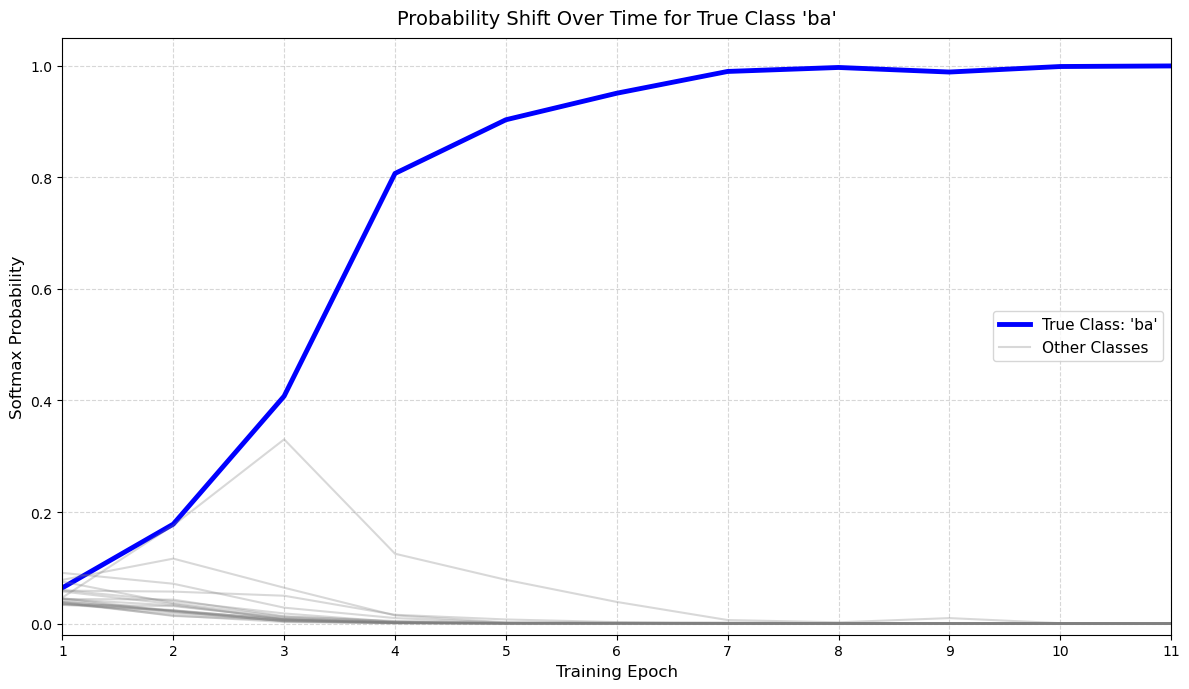

In [9]:
# Target a specific class to view its top 5 history and single-plot
target_class_name = "ba"
target_class_idx = train_dataset.class_to_idx[target_class_name]

# Extract epochs and the 20-dimensional probability vectors from our 20-image history tracking
target_history = probability_history_20[target_class_idx]
epochs = [entry[0] for entry in target_history]
probs_matrix = np.array(
    [entry[1] for entry in target_history]
)  # Shape: (num_epochs, 20)

print(f"Top 5 Predicted Classes Per Epoch for true class '{target_class_name}':")
print("=" * 60)

for list_idx, probs in enumerate(probs_matrix):
    epoch_num = epochs[list_idx]

    # Get the indices of the top 5 highest probabilities directly
    top_5_indices = np.argsort(probs)[-5:][::-1]

    print(f"Epoch {epoch_num:02d}:")
    for rank, idx in enumerate(top_5_indices, 1):
        class_name = classes[idx]
        prob = probs[idx]
        is_true_class = " <--- (True Class)" if idx == target_class_idx else ""
        print(f"  {rank}. {class_name:10s} - {prob:6.2%} {is_true_class}")
    print("-" * 40)

# Generate the visual plot below
plt.figure(figsize=(12, 7))

# Plot all 20 classes
for class_idx in range(len(classes)):
    if class_idx == target_class_idx:
        # Emphasize the TRUE tracking class (bold, visible color)
        plt.plot(
            epochs,
            probs_matrix[:, class_idx],
            color="blue",
            linewidth=3.5,
            label=f"True Class: '{target_class_name}'",
        )
    else:
        # De-emphasize the incorrect classes
        # Add a placeholder label to the legend just once for the incorrect classes
        label = (
            "Other Classes" if class_idx == (1 if target_class_idx == 0 else 0) else ""
        )
        plt.plot(
            epochs,
            probs_matrix[:, class_idx],
            color="gray",
            linewidth=1.5,
            alpha=0.3,
            label=label,
        )

# Graph styling
plt.title(
    f"Probability Shift Over Time for True Class '{target_class_name}'",
    fontsize=14,
    pad=10,
)
plt.xlabel("Training Epoch", fontsize=12)
plt.ylabel("Softmax Probability", fontsize=12)
plt.ylim(-0.02, 1.05)
plt.xlim(1, len(epochs))

# Ensure the x-ticks are integer epoch markers
plt.xticks(epochs)

# Consolidate legend to remove duplicates (like the empty labels)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc="center right", fontsize=11)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

--- Output A: True Class Probability Progression Across Epochs ---


,Epoch 1,Epoch 2,Epoch 3,Epoch 4,Epoch 5,Epoch 6,Epoch 7,Epoch 8,Epoch 9,Epoch 10,Epoch 11
ba,0.0641,0.1782,0.4078,0.8070,0.9032,0.9508,0.9898,0.9970,0.9888,0.9987,0.9997
ca,0.1190,0.2562,0.8036,0.9750,0.9904,0.9976,0.9994,0.9990,0.9995,0.9998,0.9999
da,0.0804,0.5217,0.7958,0.9713,0.9954,0.9990,0.9994,0.9995,0.9997,0.9999,0.9999
dha,0.1002,0.2568,0.7481,0.9489,0.9797,0.9881,0.9895,0.9974,0.9902,0.9982,0.9997
ga,0.0486,0.2620,0.6510,0.6368,0.8068,0.8546,0.8953,0.9625,0.9571,0.9604,0.9741
ha,0.0598,0.0673,0.1928,0.2996,0.4070,0.5295,0.9648,0.9637,0.9383,0.9879,0.9887
ja,0.1835,0.6726,0.8459,0.9606,0.9643,0.9859,0.9892,0.9913,0.9949,0.9971,0.9955
ka,0.0824,0.2147,0.4825,0.7736,0.8528,0.8805,0.9868,0.8722,0.9867,0.9976,0.9990
la,0.0599,0.1620,0.2127,0.2293,0.6394,0.8706,0.9613,0.9914,0.9934,0.9862,0.9981
ma,0.0858,0.3054,0.8078,0.9463,0.9750,0.9903,0.9890,0.9915,0.9967,0.9973,0.9971



--- Output B: 20-Class Probability Shift Grid ---


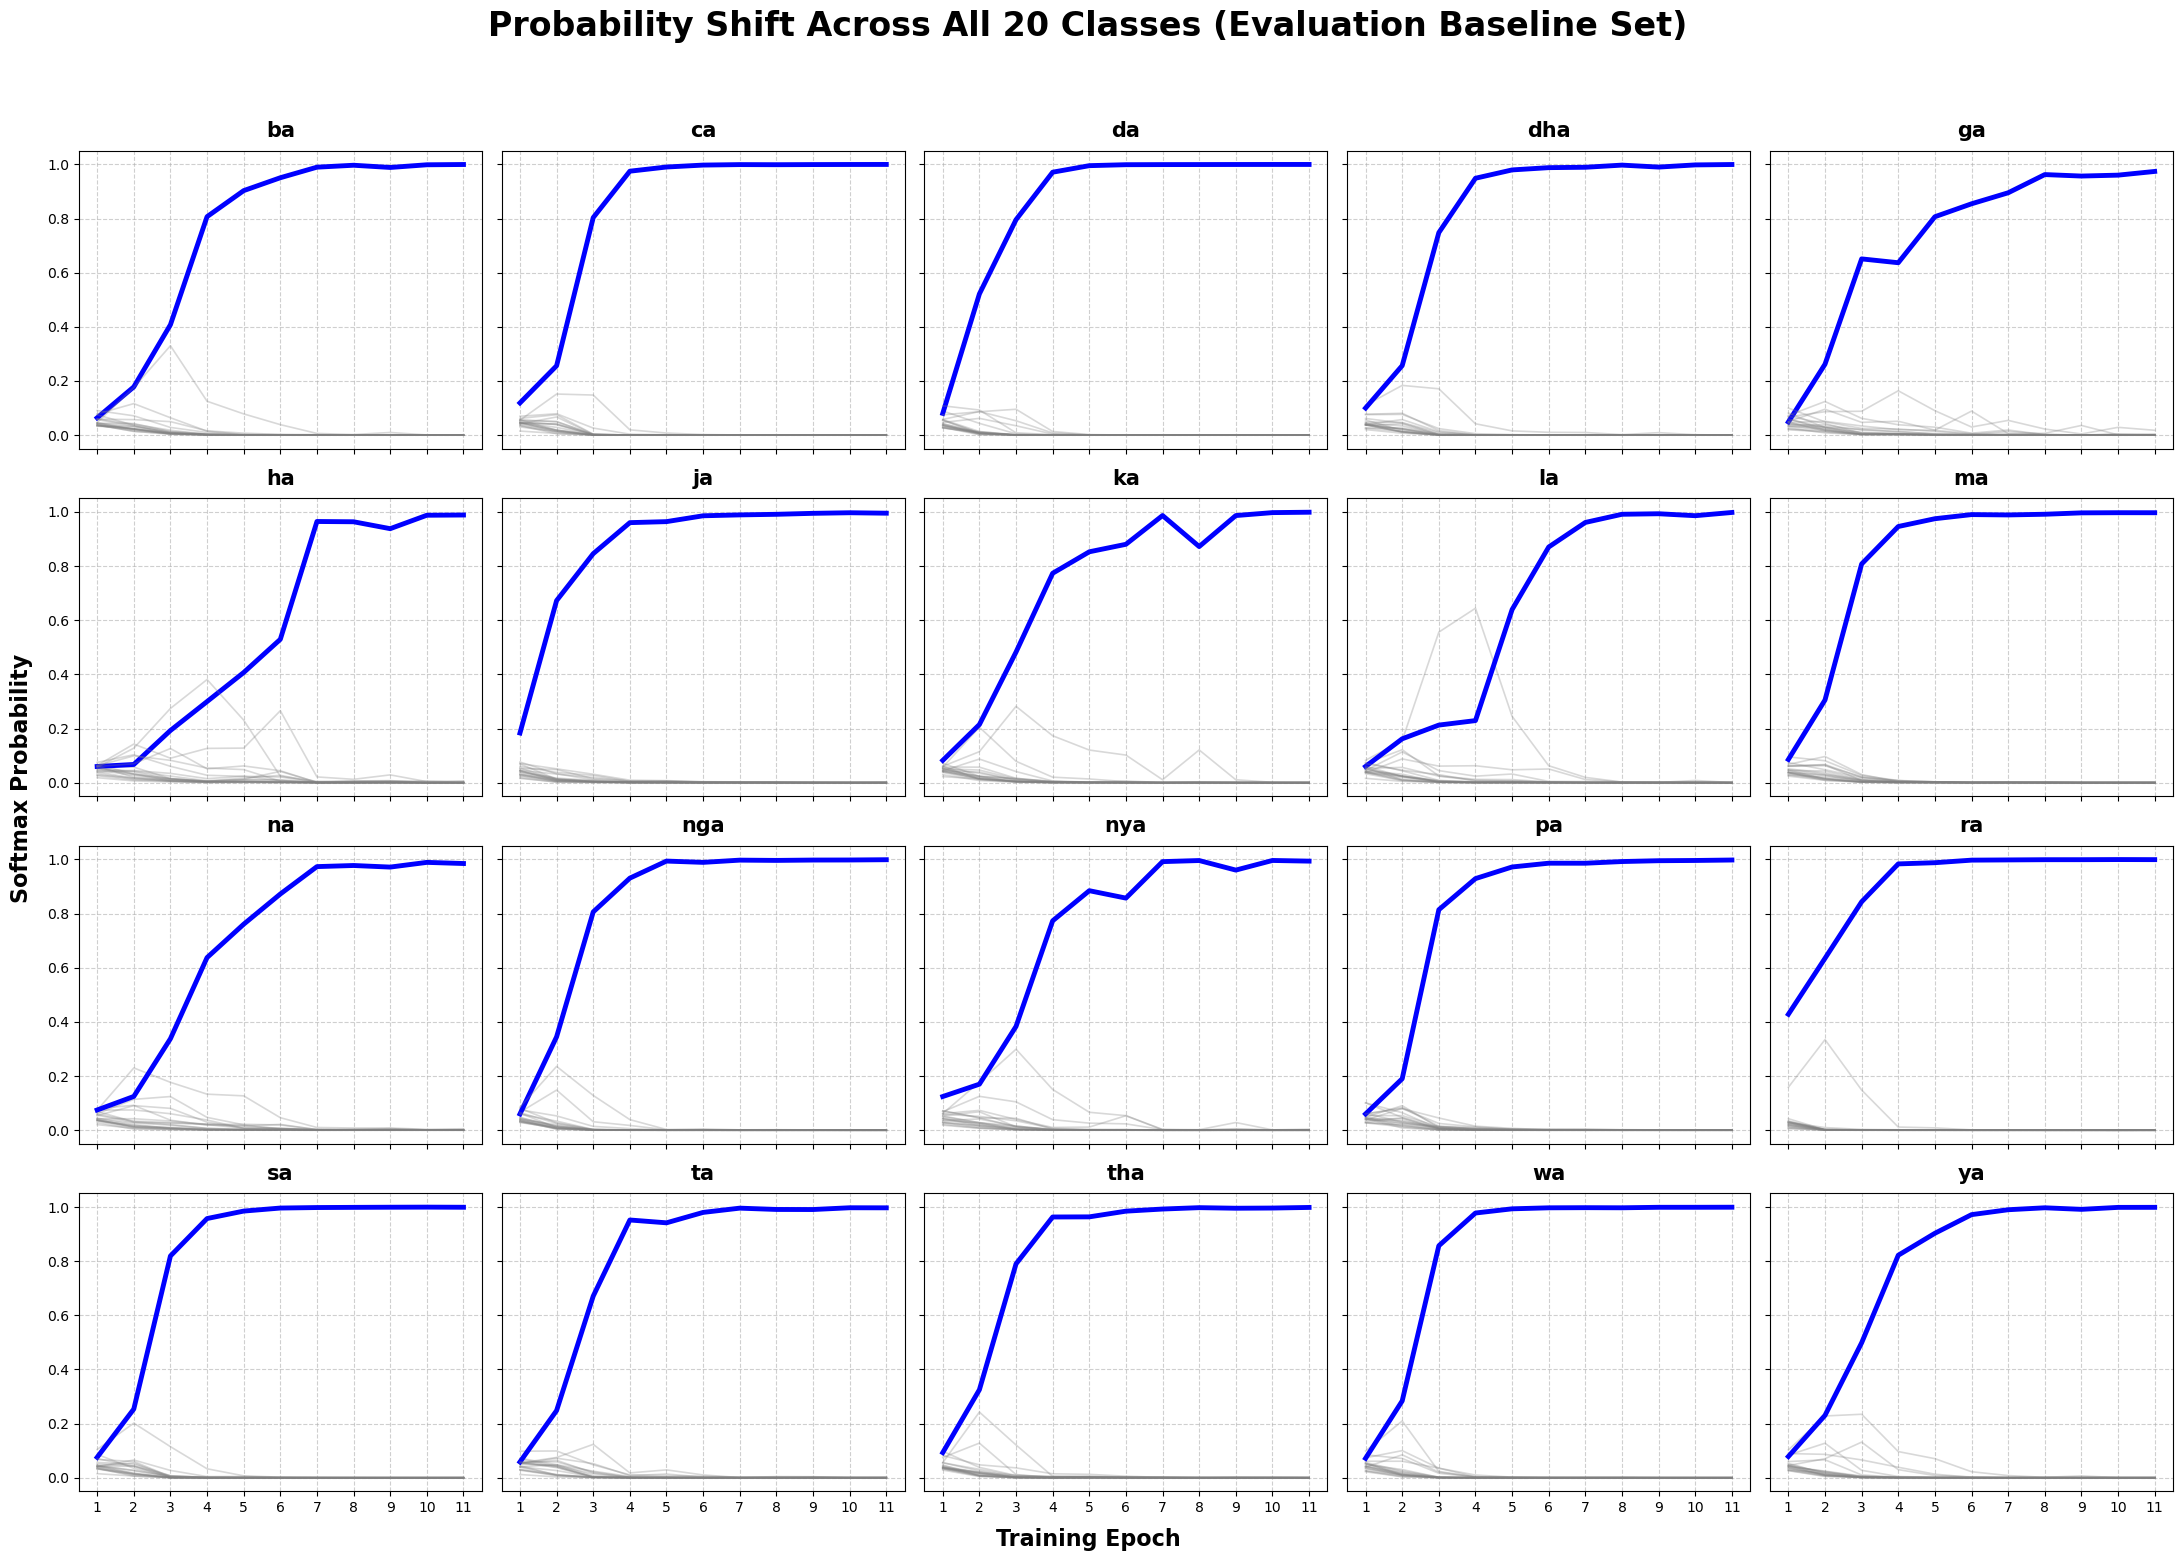

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display  # Native rendering in Jupyter

# =====================================================================
# 3. Post-Training Output A (The Epoch Table)
# =====================================================================
table_data = {}
epochs_list = []

for label_idx, history in probability_history_20.items():
    class_name = classes[label_idx]

    # Extract structural epoch list just once
    if not epochs_list:
        epochs_list = [entry[0] for entry in history]

    # Map the isolated True Class probability across all epochs
    true_class_probs = [entry[1][label_idx] for entry in history]
    table_data[class_name] = true_class_probs

# Build DataFrame: Rows=Classes, Columns=Epochs
df_probs = pd.DataFrame(table_data, index=[f"Epoch {e}" for e in epochs_list]).T
print("--- Output A: True Class Probability Progression Across Epochs ---")
display(df_probs.style.format("{:.4f}").background_gradient(cmap="Blues", axis=1))

# =====================================================================
# 4. Post-Training Output B (Visualizing the "Probability Shift" Grid)
# =====================================================================
print("\n--- Output B: 20-Class Probability Shift Grid ---")
fig, axes = plt.subplots(4, 5, figsize=(22, 16), sharex=True, sharey=True)
axes = axes.flatten()

for plot_idx, (label_idx, history) in enumerate(probability_history_20.items()):
    ax = axes[plot_idx]
    class_name = classes[label_idx]

    # Matrix shape: (num_epochs, 20)
    probs_matrix = np.array([entry[1] for entry in history])

    # Plot all 20 output classes per individual validation image
    for c_idx in range(len(classes)):
        if c_idx == label_idx:
            # Highlight the path of the true class
            ax.plot(
                epochs_list,
                probs_matrix[:, c_idx],
                color="blue",
                linewidth=3.5,
                label=f"True: {class_name}",
            )
        else:
            # De-emphasize the 19 incorrect classes
            ax.plot(
                epochs_list,
                probs_matrix[:, c_idx],
                color="gray",
                linewidth=1.2,
                alpha=0.3,
            )

    # Subplot styling
    ax.set_title(class_name, fontsize=15, fontweight="bold", pad=10)
    ax.set_ylim(-0.05, 1.05)

    # Tick structuring to keep X axis clean
    ax.set_xticks(epochs_list[:: max(1, len(epochs_list) // 10)])
    ax.grid(True, linestyle="--", alpha=0.6)

# Main figure titling & Global labels
fig.text(0.5, 0.02, "Training Epoch", ha="center", fontsize=16, fontweight="bold")
fig.text(
    0.01,
    0.5,
    "Softmax Probability",
    va="center",
    rotation="vertical",
    fontsize=16,
    fontweight="bold",
)
plt.suptitle(
    "Probability Shift Across All 20 Classes (Evaluation Baseline Set)",
    fontsize=24,
    y=0.98,
    fontweight="bold",
)

plt.tight_layout(rect=[0.02, 0.03, 1, 0.95])
plt.show()